# Experiment Design for Trust & Safety

**Objective**: Design rigorous experiments to evaluate content safety interventions on a
TikTok-like platform. This notebook covers the complete experiment lifecycle: defining
hypotheses, choosing the unit of diversion, calculating sample sizes, managing traffic
allocation with phased rollouts, handling multi-arm comparisons, and detecting novelty
effects.

**Key question from interviews**: *"Design an experiment to evaluate the effectiveness
of a new content throttling policy on reducing harmful content while preserving creator
engagement."*

We will build a full experiment design document by the end of this notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import sys, os
sys.path.insert(0, os.path.abspath('..'))

from data.generators.policy_experiments import (
    generate_ab_test_data, generate_friction_warning_test,
    generate_sequential_test_data, generate_multivariate_test,
)
from data.generators.user_behavior import generate_user_cohorts
from utils.statistical_tests import (
    sample_size_proportion, sample_size_continuous,
    two_sample_z_test, proportion_z_test,
    multiple_testing_correction, sequential_test, cuped_adjustment,
)
from utils.visualization import set_style, COLORS

set_style()
np.random.seed(42)
print("Setup complete.")

Setup complete.


## 1. Experiment Design Framework

Every experiment answers: **"Does intervention X cause outcome Y?"**

The Udacity A/B testing framework provides a structured approach:

| Step | Question | Example |
|------|----------|---------|
| 1. Metric choice | What is the OEC? What are guardrails? | OEC: violation rate; Guardrail: DAU retention |
| 2. Unit of diversion | User, session, device, page? | User-level (persistent treatment) |
| 3. Population | Who is eligible? | All users in target regions |
| 4. Duration | How long to run? | Depends on sample size + day-of-week effects |
| 5. Sample size | How many units per arm? | Power analysis → minimum detectable effect |
| 6. Randomization | How to split? | Hash-based assignment for reproducibility |

### Metric Taxonomy
- **Overall Evaluation Criterion (OEC)**: Single metric the experiment optimizes for
- **Guardrail metrics**: Must not degrade (e.g., revenue, DAU, crash rate)
- **Diagnostic metrics**: Help explain *why* OEC moved (e.g., click-through rate, time on page)
- **Data quality metrics**: Verify experiment integrity (e.g., sample ratio mismatch)

## 2. Unit of Diversion

The unit of diversion determines **what gets randomized**. This is one of the most
consequential design decisions.

| Unit | Pros | Cons | Best for |
|------|------|------|----------|
| User ID | Consistent experience, persistent | Can't measure logged-out users | Most experiments |
| Cookie/Device | Covers logged-out | Cross-device inconsistency | Sign-up funnel |
| Session | More data per unit | User sees different variants | Non-persistent changes |
| Page/Request | Maximum sample size | No consistency | Latency, rendering |
| Geo/Cluster | Avoids network effects | Fewer units → less power | Social features |

In [2]:
# Demonstrate the design effect of cluster randomization
# When users within a cluster are correlated, effective sample size shrinks

def design_effect(icc: float, cluster_size: int) -> float:
    """Compute design effect for cluster randomization.

    DEFF = 1 + (m - 1) * rho
    where m = cluster size, rho = intra-cluster correlation.
    """
    return 1 + (cluster_size - 1) * icc

# Typical scenarios for content safety
scenarios = {
    "User-level (baseline)": (0.0, 1),
    "Hashtag clusters (m=50, ICC=0.05)": (0.05, 50),
    "Creator groups (m=100, ICC=0.10)": (0.10, 100),
    "Geographic regions (m=1000, ICC=0.02)": (0.02, 1000),
    "School/org clusters (m=200, ICC=0.15)": (0.15, 200),
}

print(f"{'Scenario':<45} {'DEFF':>6} {'Effective n (from 10K)':>22}")
print("-" * 75)
for name, (icc, m) in scenarios.items():
    deff = design_effect(icc, m)
    effective_n = int(10_000 / deff)
    print(f"{name:<45} {deff:>6.1f} {effective_n:>22,}")

Scenario                                        DEFF Effective n (from 10K)
---------------------------------------------------------------------------
User-level (baseline)                            1.0                 10,000
Hashtag clusters (m=50, ICC=0.05)                3.5                  2,898
Creator groups (m=100, ICC=0.10)                10.9                    917
Geographic regions (m=1000, ICC=0.02)           21.0                    476
School/org clusters (m=200, ICC=0.15)           30.8                    324


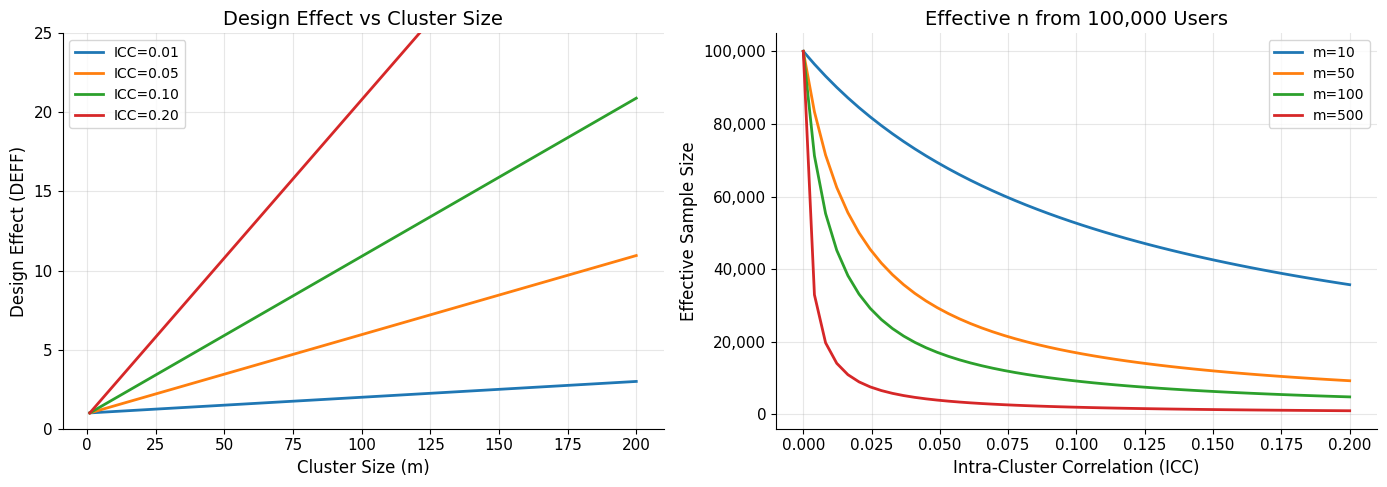

In [3]:
# Visualize: how ICC and cluster size affect the design effect
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: DEFF vs cluster size for different ICCs
cluster_sizes = np.arange(1, 201)
for icc, label in [(0.01, "ICC=0.01"), (0.05, "ICC=0.05"), (0.10, "ICC=0.10"), (0.20, "ICC=0.20")]:
    deffs = [design_effect(icc, m) for m in cluster_sizes]
    axes[0].plot(cluster_sizes, deffs, label=label, linewidth=2)

axes[0].set_xlabel("Cluster Size (m)")
axes[0].set_ylabel("Design Effect (DEFF)")
axes[0].set_title("Design Effect vs Cluster Size")
axes[0].legend()
axes[0].set_ylim(0, 25)

# Right: Effective sample size (starting from 100K users)
N_total = 100_000
iccs = np.linspace(0, 0.20, 50)
for m, label in [(10, "m=10"), (50, "m=50"), (100, "m=100"), (500, "m=500")]:
    effective = [N_total / design_effect(icc, m) for icc in iccs]
    axes[1].plot(iccs, effective, label=label, linewidth=2)

axes[1].set_xlabel("Intra-Cluster Correlation (ICC)")
axes[1].set_ylabel("Effective Sample Size")
axes[1].set_title(f"Effective n from {N_total:,} Users")
axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"{x:,.0f}"))

plt.tight_layout()
plt.show()

## 3. Sample Size Optimization

Sample size determines the **minimum detectable effect (MDE)** — the smallest true
effect we can reliably detect. The key formula for proportions:

$$n = \left(\frac{z_{\alpha/2}\sqrt{2p(1-p)} + z_{\beta}\sqrt{p_1(1-p_1) + p_2(1-p_2)}}{\delta}\right)^2$$

where $\delta = p_2 - p_1$ is the MDE.

**Content safety twist**: Violation rates are typically very low (1-5%), so:
1. You need large samples to detect small absolute changes
2. Relative effects (e.g., 20% reduction) matter more than absolute effects
3. The variance term $p(1-p)$ is small, which helps

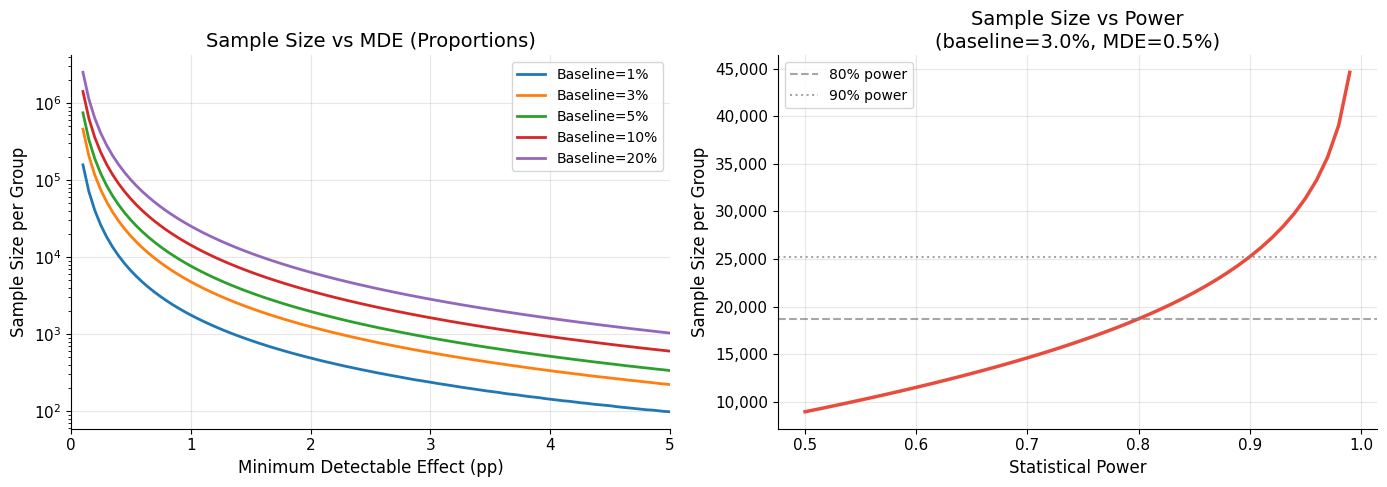


=== Content Safety Sample Size Calculator ===
Scenario                              n/group (80%)   n/group (90%)  Total (80%)
--------------------------------------------------------------------------------
Violation rate: 3% -> 2.5%                   18,708          25,230       37,416
Violation rate: 3% -> 2.7%                   51,487          69,237      102,974
Report rate: 5% -> 4%                         7,664          10,347       15,328
Appeal overturn: 10% -> 8%                    3,623           4,889        7,246
User churn: 2% -> 1.5%                       12,749          17,256       25,498


In [4]:
# Sample size sensitivity analysis for content safety metrics

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: sample size vs MDE for different baseline rates
baseline_rates = [0.01, 0.03, 0.05, 0.10, 0.20]
mdes = np.linspace(0.001, 0.05, 100)

for br in baseline_rates:
    sample_sizes = []
    for mde in mdes:
        if br + mde > 1:
            sample_sizes.append(np.nan)
        else:
            n = sample_size_proportion(br, mde, alpha=0.05, power=0.80)
            sample_sizes.append(n)
    axes[0].plot(mdes * 100, sample_sizes, label=f"Baseline={br:.0%}", linewidth=2)

axes[0].set_xlabel("Minimum Detectable Effect (pp)")
axes[0].set_ylabel("Sample Size per Group")
axes[0].set_title("Sample Size vs MDE (Proportions)")
axes[0].set_yscale("log")
axes[0].legend()
axes[0].set_xlim(0, 5)

# Right panel: sample size vs power for a typical safety metric
baseline = 0.03
mde_abs = 0.005  # 0.5 pp reduction
powers = np.linspace(0.50, 0.99, 50)
n_per_power = [sample_size_proportion(baseline, mde_abs, power=p) for p in powers]

axes[1].plot(powers, n_per_power, color=COLORS["treatment"], linewidth=2.5)
axes[1].axhline(sample_size_proportion(baseline, mde_abs, power=0.80),
               color="gray", linestyle="--", alpha=0.7, label="80% power")
axes[1].axhline(sample_size_proportion(baseline, mde_abs, power=0.90),
               color="gray", linestyle=":", alpha=0.7, label="90% power")
axes[1].set_xlabel("Statistical Power")
axes[1].set_ylabel("Sample Size per Group")
axes[1].set_title(f"Sample Size vs Power\n(baseline={baseline:.1%}, MDE={mde_abs:.1%})")
axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"{x:,.0f}"))

plt.tight_layout()
plt.show()

# Print key sample size calculations
print("\n=== Content Safety Sample Size Calculator ===")
cases = [
    ("Violation rate: 3% -> 2.5%", 0.03, 0.005),
    ("Violation rate: 3% -> 2.7%", 0.03, 0.003),
    ("Report rate: 5% -> 4%", 0.05, 0.01),
    ("Appeal overturn: 10% -> 8%", 0.10, 0.02),
    ("User churn: 2% -> 1.5%", 0.02, 0.005),
]
print(f"{'Scenario':<35} {'n/group (80%)':>15} {'n/group (90%)':>15} {'Total (80%)':>12}")
print("-" * 80)
for name, base, mde in cases:
    n80 = sample_size_proportion(base, mde, power=0.80)
    n90 = sample_size_proportion(base, mde, power=0.90)
    print(f"{name:<35} {n80:>15,} {n90:>15,} {2*n80:>12,}")

In [5]:
# Continuous metric sample sizes (engagement metrics)
print("=== Continuous Metric Sample Sizes ===")
print(f"{'Scenario':<40} {'n/group (80%)':>15} {'n/group (90%)':>15}")
print("-" * 72)

continuous_cases = [
    ("Time spent: std=15min, MDE=1min", 15, 1),
    ("Time spent: std=15min, MDE=2min", 15, 2),
    ("Trust score: std=0.15, MDE=0.02", 0.15, 0.02),
    ("Sessions/day: std=3, MDE=0.5", 3, 0.5),
    ("Watch-through rate: std=0.20, MDE=0.01", 0.20, 0.01),
]
for name, std, mde in continuous_cases:
    n80 = sample_size_continuous(std, mde, power=0.80)
    n90 = sample_size_continuous(std, mde, power=0.90)
    print(f"{name:<40} {n80:>15,} {n90:>15,}")

# Duration estimation
print("\n=== Experiment Duration Estimates ===")
dau = 500_000  # hypothetical DAU for eligible population
traffic_fractions = [0.05, 0.10, 0.25, 0.50, 1.00]
n_needed = sample_size_proportion(0.03, 0.005, power=0.80)
print(f"Required n/group: {n_needed:,} (violation rate 3% -> 2.5%)")
print(f"Eligible DAU: {dau:,}")
print(f"{'Traffic %':<15} {'Users/day/arm':>15} {'Days needed':>12}")
print("-" * 45)
for frac in traffic_fractions:
    users_per_arm_per_day = int(dau * frac / 2)
    days = int(np.ceil(n_needed / users_per_arm_per_day))
    print(f"{frac:.0%}{'':<12} {users_per_arm_per_day:>15,} {days:>12}")

=== Continuous Metric Sample Sizes ===
Scenario                                   n/group (80%)   n/group (90%)
------------------------------------------------------------------------
Time spent: std=15min, MDE=1min                    3,532           4,729
Time spent: std=15min, MDE=2min                      883           1,183
Trust score: std=0.15, MDE=0.02                      883           1,183
Sessions/day: std=3, MDE=0.5                         566             757
Watch-through rate: std=0.20, MDE=0.01             6,280           8,406

=== Experiment Duration Estimates ===
Required n/group: 18,708 (violation rate 3% -> 2.5%)
Eligible DAU: 500,000
Traffic %         Users/day/arm  Days needed
---------------------------------------------
5%                      12,500            2
10%                      25,000            1
25%                      62,500            1
50%                     125,000            1
100%                     250,000            1


## 4. Traffic Allocation & Phased Rollouts

In practice, experiments don't start at 50/50 immediately. Phased rollouts manage risk:

| Phase | Traffic | Duration | Purpose |
|-------|---------|----------|---------|
| Canary | 1% | 1-2 days | Catch crashes, data pipeline issues |
| Ramp 1 | 5% | 3-5 days | Early signal, SRM check |
| Ramp 2 | 10-25% | 1-2 weeks | Power-adequate for primary metrics |
| Full | 50% | Until MDE reached | Final analysis |

### Key safety checks at each ramp:
1. **Sample Ratio Mismatch (SRM)**: Chi-squared test that actual ratios match expected
2. **Guardrail monitoring**: No degradation in critical metrics
3. **Data quality**: Logging works, no missing data spikes

In [6]:
# Simulate a phased rollout with SRM checks
rng = np.random.default_rng(42)

phases = [
    {"name": "Canary", "traffic_pct": 0.01, "days": 2, "daily_users": 500_000},
    {"name": "Ramp 1", "traffic_pct": 0.05, "days": 5, "daily_users": 500_000},
    {"name": "Ramp 2", "traffic_pct": 0.10, "days": 7, "daily_users": 500_000},
    {"name": "Ramp 3", "traffic_pct": 0.25, "days": 7, "daily_users": 500_000},
    {"name": "Full", "traffic_pct": 0.50, "days": 14, "daily_users": 500_000},
]

print("=== Phased Rollout Plan ===")
print(f"{'Phase':<12} {'Traffic':>8} {'Days':>6} {'Users/arm':>12} {'Cumul. Users':>14} {'MDE (prop)':>12}")
print("-" * 68)

cumulative = 0
for phase in phases:
    users_per_arm = int(phase["daily_users"] * phase["traffic_pct"] / 2) * phase["days"]
    cumulative += users_per_arm
    p = 0.03
    z_a = stats.norm.ppf(0.975)
    z_b = stats.norm.ppf(0.80)
    mde_approx = (z_a + z_b) * np.sqrt(2 * p * (1 - p) / max(cumulative, 1))
    print(f"{phase['name']:<12} {phase['traffic_pct']:>7.0%} {phase['days']:>6} "
          f"{users_per_arm:>12,} {cumulative:>14,} {mde_approx:>12.4f}")

=== Phased Rollout Plan ===
Phase         Traffic   Days    Users/arm   Cumul. Users   MDE (prop)
--------------------------------------------------------------------
Canary            1%      2        5,000          5,000       0.0096
Ramp 1            5%      5       62,500         67,500       0.0026
Ramp 2           10%      7      175,000        242,500       0.0014
Ramp 3           25%      7      437,500        680,000       0.0008
Full             50%     14    1,750,000      2,430,000       0.0004


In [7]:
# SRM (Sample Ratio Mismatch) detection
def check_srm(n_control: int, n_treatment: int, expected_ratio: float = 1.0) -> dict:
    """Chi-squared test for Sample Ratio Mismatch."""
    total = n_control + n_treatment
    expected_control = total / (1 + expected_ratio)
    expected_treatment = total * expected_ratio / (1 + expected_ratio)
    chi2 = ((n_control - expected_control)**2 / expected_control +
            (n_treatment - expected_treatment)**2 / expected_treatment)
    p_value = 1 - stats.chi2.cdf(chi2, df=1)
    return {
        "chi2": chi2,
        "p_value": p_value,
        "srm_detected": p_value < 0.001,
        "actual_ratio": n_treatment / n_control if n_control > 0 else float("inf"),
        "expected_ratio": expected_ratio,
    }

# Simulate SRM checks across rollout phases
print("=== SRM Checks During Rollout ===")
print()

# Normal case: no SRM
rng = np.random.default_rng(42)
for total in [1000, 5000, 25000, 100000]:
    n_treat = rng.binomial(total, 0.5)
    n_ctrl = total - n_treat
    result = check_srm(n_ctrl, n_treat)
    status = "SRM!" if result["srm_detected"] else "OK"
    print(f"n={total:>7,}: control={n_ctrl:,}, treatment={n_treat:,}, "
          f"ratio={result['actual_ratio']:.4f}, p={result['p_value']:.4f} [{status}]")

print("\n--- Introducing a bug (treatment logging drops 2% of users) ---")
for total in [1000, 5000, 25000, 100000]:
    n_treat = int(rng.binomial(total, 0.5) * 0.98)
    n_ctrl = total - int(total * 0.5)
    result = check_srm(n_ctrl, n_treat)
    status = "SRM!" if result["srm_detected"] else "OK"
    print(f"n={total:>7,}: control={n_ctrl:,}, treatment={n_treat:,}, "
          f"ratio={result['actual_ratio']:.4f}, p={result['p_value']:.4f} [{status}]")

=== SRM Checks During Rollout ===

n=  1,000: control=513, treatment=487, ratio=0.9493, p=0.4110 [OK]
n=  5,000: control=2,564, treatment=2,436, ratio=0.9501, p=0.0703 [OK]
n= 25,000: control=12,548, treatment=12,452, ratio=0.9923, p=0.5437 [OK]
n=100,000: control=50,150, treatment=49,850, ratio=0.9940, p=0.3428 [OK]

--- Introducing a bug (treatment logging drops 2% of users) ---
n=  1,000: control=500, treatment=492, ratio=0.9840, p=0.7995 [OK]
n=  5,000: control=2,500, treatment=2,477, ratio=0.9908, p=0.7444 [OK]
n= 25,000: control=12,500, treatment=12,362, ratio=0.9890, p=0.3815 [OK]
n=100,000: control=50,000, treatment=48,905, ratio=0.9781, p=0.0005 [SRM!]


## 5. Multi-Arm Bandits: Thompson Sampling

When testing multiple interventions, traditional A/B testing allocates equal traffic to
all arms. **Thompson Sampling** adaptively allocates more traffic to better-performing
arms, reducing regret.

**Content safety application**: Testing multiple warning types (mild, strong, educational)
simultaneously while minimizing user exposure to ineffective interventions.

In [8]:
# Thompson Sampling for Bernoulli bandits
class ThompsonSampling:
    def __init__(self, n_arms: int, prior_alpha: float = 1.0, prior_beta: float = 1.0):
        self.n_arms = n_arms
        self.alpha = np.full(n_arms, prior_alpha)
        self.beta = np.full(n_arms, prior_beta)

    def select_arm(self, rng: np.random.Generator) -> int:
        samples = rng.beta(self.alpha, self.beta)
        return int(np.argmax(samples))

    def update(self, arm: int, reward: int):
        if reward:
            self.alpha[arm] += 1
        else:
            self.beta[arm] += 1

    def get_stats(self) -> pd.DataFrame:
        means = self.alpha / (self.alpha + self.beta)
        pulls = (self.alpha - 1) + (self.beta - 1)
        return pd.DataFrame({
            "arm": range(self.n_arms),
            "pulls": pulls.astype(int),
            "mean_reward": np.round(means, 4),
            "alpha": self.alpha,
            "beta": self.beta,
        })

# Simulate: 4 warning types with different effectiveness
true_probs = [0.10, 0.15, 0.25, 0.18]
arm_names = ["No warning", "Mild warning", "Strong warning", "Educational"]

rng = np.random.default_rng(42)
bandit = ThompsonSampling(n_arms=4)

n_rounds = 5000
rewards_over_time = []
arm_selections = []

for t in range(n_rounds):
    arm = bandit.select_arm(rng)
    reward = rng.binomial(1, true_probs[arm])
    bandit.update(arm, reward)
    arm_selections.append(arm)
    rewards_over_time.append(reward)

stats_df = bandit.get_stats()
stats_df["arm_name"] = arm_names
stats_df["true_prob"] = true_probs
print("=== Thompson Sampling Results (5,000 rounds) ===")
print(stats_df[["arm_name", "pulls", "mean_reward", "true_prob"]].to_string(index=False))

=== Thompson Sampling Results (5,000 rounds) ===
      arm_name  pulls  mean_reward  true_prob
    No warning     35       0.0541       0.10
  Mild warning    109       0.1261       0.15
Strong warning   4791       0.2491       0.25
   Educational     65       0.1343       0.18


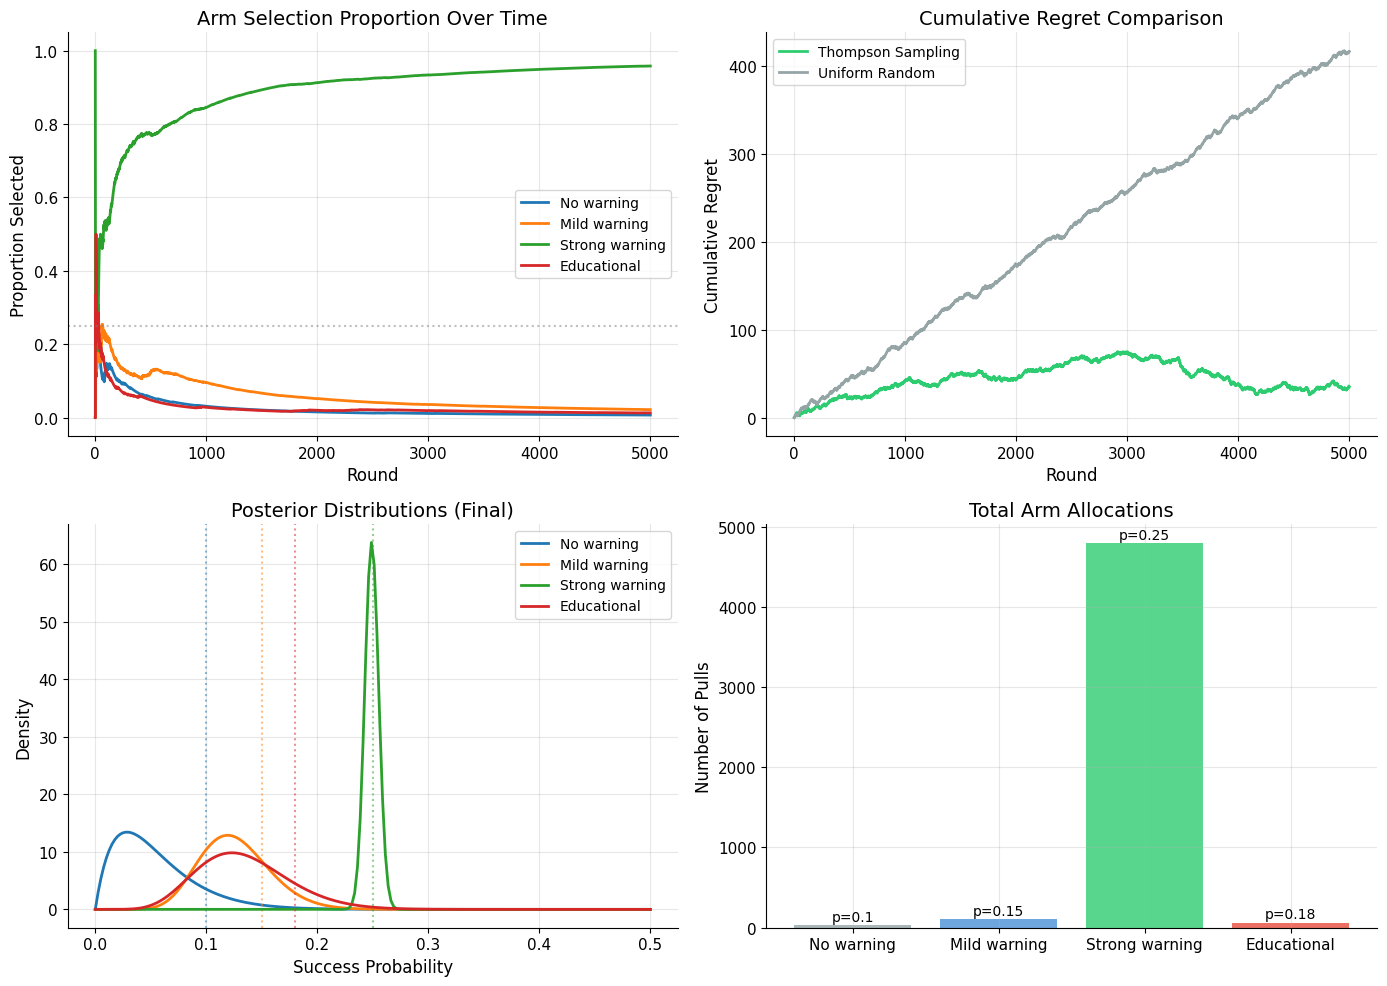


Best arm identified: Strong warning
True best arm: Strong warning
Traffic to best arm: 95.8%


In [9]:
# Visualize Thompson Sampling behavior
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: Cumulative arm selection proportions
selection_arr = np.array(arm_selections)
cum_props = np.zeros((n_rounds, 4))
for t in range(n_rounds):
    for a in range(4):
        cum_props[t, a] = np.mean(selection_arr[:t+1] == a)

for a in range(4):
    axes[0, 0].plot(cum_props[:, a], label=arm_names[a], linewidth=2)
axes[0, 0].set_xlabel("Round")
axes[0, 0].set_ylabel("Proportion Selected")
axes[0, 0].set_title("Arm Selection Proportion Over Time")
axes[0, 0].legend()
axes[0, 0].axhline(0.25, color="gray", linestyle=":", alpha=0.5)

# Top-right: Cumulative regret vs uniform allocation
optimal_prob = max(true_probs)
bandit_rewards = np.cumsum(rewards_over_time)
optimal_rewards = np.arange(1, n_rounds + 1) * optimal_prob
regret = optimal_rewards - bandit_rewards

uniform_rewards = []
for t in range(n_rounds):
    arm = rng.integers(0, 4)
    reward = rng.binomial(1, true_probs[arm])
    uniform_rewards.append(reward)
uniform_regret = optimal_rewards - np.cumsum(uniform_rewards)

axes[0, 1].plot(regret, label="Thompson Sampling", linewidth=2, color=COLORS["accent"])
axes[0, 1].plot(uniform_regret, label="Uniform Random", linewidth=2, color=COLORS["neutral"])
axes[0, 1].set_xlabel("Round")
axes[0, 1].set_ylabel("Cumulative Regret")
axes[0, 1].set_title("Cumulative Regret Comparison")
axes[0, 1].legend()

# Bottom-left: Final posterior distributions
x = np.linspace(0, 0.5, 200)
for a in range(4):
    y = stats.beta.pdf(x, bandit.alpha[a], bandit.beta[a])
    axes[1, 0].plot(x, y, label=arm_names[a], linewidth=2)
    axes[1, 0].axvline(true_probs[a], color=f"C{a}", linestyle=":", alpha=0.5)
axes[1, 0].set_xlabel("Success Probability")
axes[1, 0].set_ylabel("Density")
axes[1, 0].set_title("Posterior Distributions (Final)")
axes[1, 0].legend()

# Bottom-right: Total pulls per arm
colors_bar = [COLORS["neutral"], COLORS["control"], COLORS["accent"], COLORS["treatment"]]
axes[1, 1].bar(arm_names, stats_df["pulls"], color=colors_bar, alpha=0.8)
axes[1, 1].set_ylabel("Number of Pulls")
axes[1, 1].set_title("Total Arm Allocations")
for i, (v, tp) in enumerate(zip(stats_df["pulls"], true_probs)):
    axes[1, 1].text(i, v + 50, f"p={tp}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nBest arm identified: {arm_names[int(stats_df['mean_reward'].idxmax())]}")
print(f"True best arm: {arm_names[np.argmax(true_probs)]}")
print(f"Traffic to best arm: {cum_props[-1, np.argmax(true_probs)]:.1%}")

## 6. Novelty & Primacy Effects

Novelty effects are a major threat to experiment validity in content safety:
- Users may initially comply more with warnings (novelty) then habituate
- Creators may temporarily reduce violations after policy announcement (Hawthorne effect)
- Engagement dips from friction features may recover as users adapt

**Detection strategies**:
1. Compare effect sizes across cohorts (users who entered early vs late)
2. Plot the treatment effect over time — look for trend changes
3. Run a "holdback" group that joins treatment late

In [10]:
# Generate sequential test data with built-in novelty effect
seq_data = generate_sequential_test_data(
    n_users_per_day=500, n_days=30, effect_size=0.03, seed=42
)
print(f"Sequential data shape: {seq_data.shape}")
print(f"Columns: {list(seq_data.columns)}")
print(f"Day range: {seq_data['day'].min()} to {seq_data['day'].max()}")

# Compute daily treatment effects
daily_effects = []
for day in sorted(seq_data["day"].unique()):
    day_data = seq_data[seq_data["day"] == day]
    ctrl = day_data[day_data["group"] == "control"]["metric_value"].values
    treat = day_data[day_data["group"] == "treatment"]["metric_value"].values
    if len(ctrl) > 10 and len(treat) > 10:
        effect = np.mean(treat) - np.mean(ctrl)
        se = np.sqrt(np.var(ctrl)/len(ctrl) + np.var(treat)/len(treat))
        daily_effects.append({"day": day, "effect": effect, "se": se})

effects_df = pd.DataFrame(daily_effects)
print(f"\nDaily effects computed for {len(effects_df)} days")

Sequential data shape: (14974, 5)
Columns: ['day', 'user_id', 'group', 'metric_value', 'cumulative_users']
Day range: 1 to 30

Daily effects computed for 30 days


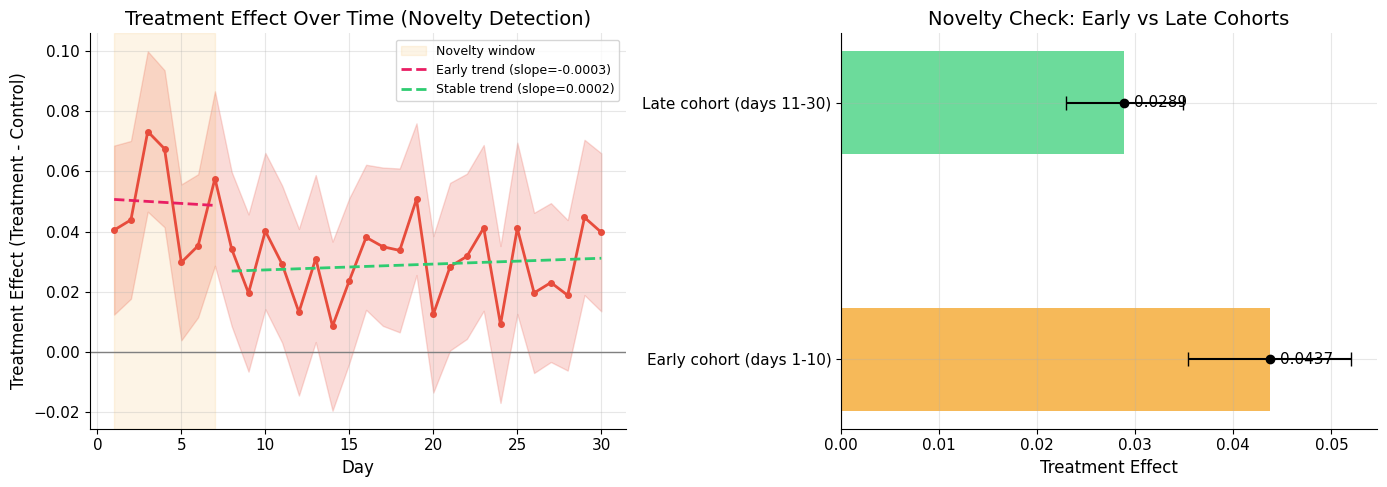


Novelty test: early effect = 0.0437, late effect = 0.0289
Difference = 0.0149, z = 2.84, p = 0.0045
Novelty effect detected at alpha=0.05


In [11]:
# Visualize novelty effect detection
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Daily treatment effects over time
axes[0].plot(effects_df["day"], effects_df["effect"], "o-",
            color=COLORS["treatment"], linewidth=2, markersize=4)
axes[0].fill_between(effects_df["day"],
                    effects_df["effect"] - 1.96 * effects_df["se"],
                    effects_df["effect"] + 1.96 * effects_df["se"],
                    alpha=0.2, color=COLORS["treatment"])
axes[0].axhline(0, color="gray", linestyle="-", linewidth=1)

# Mark the novelty period (first 7 days)
axes[0].axvspan(1, 7, alpha=0.1, color=COLORS["warning"], label="Novelty window")

# Fit trend lines for novelty vs stable periods
early = effects_df[effects_df["day"] <= 7]
late = effects_df[effects_df["day"] > 7]

if len(early) > 2:
    z_early = np.polyfit(early["day"], early["effect"], 1)
    axes[0].plot(early["day"], np.polyval(z_early, early["day"]),
                "--", color=COLORS["danger"], linewidth=2, label=f"Early trend (slope={z_early[0]:.4f})")

if len(late) > 2:
    z_late = np.polyfit(late["day"], late["effect"], 1)
    axes[0].plot(late["day"], np.polyval(z_late, late["day"]),
                "--", color=COLORS["accent"], linewidth=2, label=f"Stable trend (slope={z_late[0]:.4f})")

axes[0].set_xlabel("Day")
axes[0].set_ylabel("Treatment Effect (Treatment - Control)")
axes[0].set_title("Treatment Effect Over Time (Novelty Detection)")
axes[0].legend(fontsize=9)

# Right: Cohort comparison
early_data = seq_data[seq_data["day"] <= 10]
late_data = seq_data[seq_data["day"] > 10]

cohort_effects = []
for label, subset in [("Early cohort (days 1-10)", early_data), ("Late cohort (days 11-30)", late_data)]:
    ctrl = subset[subset["group"] == "control"]["metric_value"].values
    treat = subset[subset["group"] == "treatment"]["metric_value"].values
    effect = np.mean(treat) - np.mean(ctrl)
    se = np.sqrt(np.var(ctrl)/len(ctrl) + np.var(treat)/len(treat))
    cohort_effects.append({"cohort": label, "effect": effect, "se": se})

cohort_df = pd.DataFrame(cohort_effects)
colors_cohort = [COLORS["warning"], COLORS["accent"]]
axes[1].barh(range(len(cohort_df)), cohort_df["effect"], color=colors_cohort, alpha=0.7, height=0.4)
axes[1].errorbar(cohort_df["effect"], range(len(cohort_df)),
                xerr=1.96 * cohort_df["se"], fmt="o", color="black", capsize=5)
axes[1].set_yticks(range(len(cohort_df)))
axes[1].set_yticklabels(cohort_df["cohort"])
axes[1].axvline(0, color="gray", linestyle="-")
axes[1].set_xlabel("Treatment Effect")
axes[1].set_title("Novelty Check: Early vs Late Cohorts")

for i, row in cohort_df.iterrows():
    axes[1].text(row["effect"] + 0.001, i, f"{row['effect']:.4f}", va="center")

plt.tight_layout()
plt.show()

# Statistical test for novelty
early_effect = cohort_df.iloc[0]["effect"]
late_effect = cohort_df.iloc[1]["effect"]
pooled_se = np.sqrt(cohort_df.iloc[0]["se"]**2 + cohort_df.iloc[1]["se"]**2)
z_novelty = (early_effect - late_effect) / pooled_se if pooled_se > 0 else 0
p_novelty = 2 * (1 - stats.norm.cdf(abs(z_novelty)))
print(f"\nNovelty test: early effect = {early_effect:.4f}, late effect = {late_effect:.4f}")
print(f"Difference = {early_effect - late_effect:.4f}, z = {z_novelty:.2f}, p = {p_novelty:.4f}")
print(f"Novelty effect {'detected' if p_novelty < 0.05 else 'not detected'} at alpha=0.05")

## 7. Full Experiment Design Document: Content Throttling Policy

**Scenario**: TikTok is considering a new policy that automatically throttles the
distribution of content from creators who have accumulated 3+ confirmed violations in
the past 30 days. Throttled creators see their content recommended 50% less frequently.

This is a worked example of a complete design document, the kind of deliverable an
Integrity & Safety DS would produce.

In [12]:
# Load data for the case study
ab_data = generate_ab_test_data(n_users=10_000, effect_size=0.05, seed=42)
friction_data = generate_friction_warning_test(n_users=8_000, seed=42)
mv_data = generate_multivariate_test(n_users=15_000, seed=42)

print("=== Experiment Design Document: Content Throttling ===")
print("=" * 55)
print()
print("1. HYPOTHESIS")
print("-" * 40)
print("H0: Throttling high-violation creators has no effect on platform violation rate")
print("H1: Throttling reduces the overall violation rate by >= 0.5 pp (from 3% to <= 2.5%)")
print()
print("2. METRICS")
print("-" * 40)
print("OEC: Violation rate (confirmed violations / total content reviewed)")
print("Guardrail metrics:")
print("  - Creator DAU retention (must not drop > 2%)")
print("  - Total content creation volume (must not drop > 5%)")
print("  - User satisfaction score (must not drop > 0.5 pp)")
print("Diagnostic metrics:")
print("  - Throttled creator engagement (time spent, sessions)")
print("  - Non-throttled creator engagement (spillover check)")
print("  - Content diversity index")
print("Data quality:")
print("  - Sample Ratio Mismatch (SRM) < 0.001 threshold")
print("  - Logging completeness >= 99.5%")

=== Experiment Design Document: Content Throttling ===

1. HYPOTHESIS
----------------------------------------
H0: Throttling high-violation creators has no effect on platform violation rate
H1: Throttling reduces the overall violation rate by >= 0.5 pp (from 3% to <= 2.5%)

2. METRICS
----------------------------------------
OEC: Violation rate (confirmed violations / total content reviewed)
Guardrail metrics:
  - Creator DAU retention (must not drop > 2%)
  - Total content creation volume (must not drop > 5%)
  - User satisfaction score (must not drop > 0.5 pp)
Diagnostic metrics:
  - Throttled creator engagement (time spent, sessions)
  - Non-throttled creator engagement (spillover check)
  - Content diversity index
Data quality:
  - Sample Ratio Mismatch (SRM) < 0.001 threshold
  - Logging completeness >= 99.5%


In [13]:
# 3. Sample size calculation
print("3. SAMPLE SIZE & DURATION")
print("-" * 40)

n_primary = sample_size_proportion(0.03, 0.005, alpha=0.05, power=0.80)
n_primary_90 = sample_size_proportion(0.03, 0.005, alpha=0.05, power=0.90)
n_guardrail = sample_size_proportion(0.85, 0.02, alpha=0.05, power=0.80)
n_content = sample_size_continuous(5.0, 0.5, alpha=0.05, power=0.80)

required_n = max(n_primary, n_guardrail, n_content)
print(f"Primary metric (violation rate):     {n_primary:>8,} per arm (80% power)")
print(f"Primary metric (violation rate):     {n_primary_90:>8,} per arm (90% power)")
print(f"Guardrail (creator retention):       {n_guardrail:>8,} per arm")
print(f"Guardrail (content volume):          {n_content:>8,} per arm")
print(f"Binding constraint:                  {required_n:>8,} per arm")
print()

dau_eligible = 200_000
print(f"Eligible population: ~{dau_eligible:,} DAU")
print(f"{'Traffic %':<12} {'n/arm/day':>12} {'Days to n':>10} {'Recommendation':>20}")
print("-" * 58)
for frac in [0.05, 0.10, 0.25, 0.50]:
    n_per_day = int(dau_eligible * frac / 2)
    days = int(np.ceil(required_n / max(n_per_day, 1)))
    rec = "Recommended" if 14 <= days <= 42 else ("Too short" if days < 14 else "Too long")
    print(f"{frac:>7.0%}     {n_per_day:>12,} {days:>10} {rec:>20}")

3. SAMPLE SIZE & DURATION
----------------------------------------
Primary metric (violation rate):       18,708 per arm (80% power)
Primary metric (violation rate):       25,230 per arm (90% power)
Guardrail (creator retention):          4,918 per arm
Guardrail (content volume):             1,570 per arm
Binding constraint:                    18,708 per arm

Eligible population: ~200,000 DAU
Traffic %       n/arm/day  Days to n       Recommendation
----------------------------------------------------------
     5%            5,000          4            Too short
    10%           10,000          2            Too short
    25%           25,000          1            Too short
    50%           50,000          1            Too short


In [14]:
# 4. Randomization design with balance check
print("4. RANDOMIZATION & BALANCE CHECK")
print("-" * 40)

ctrl = ab_data[ab_data["group"] == "control"]
treat = ab_data[ab_data["group"] == "treatment"]

balance_vars = ["pre_engagement_rate", "pre_trust_score", "sessions",
                "time_spent_minutes", "account_age_days"]

print(f"{'Covariate':<25} {'Control Mean':>14} {'Treatment Mean':>16} {'Diff':>8} {'p-value':>10}")
print("-" * 76)
for var in balance_vars:
    c_mean = ctrl[var].mean()
    t_mean = treat[var].mean()
    t_stat, p_val = stats.ttest_ind(ctrl[var], treat[var])
    diff = t_mean - c_mean
    flag = " *" if p_val < 0.05 else ""
    print(f"{var:<25} {c_mean:>14.4f} {t_mean:>16.4f} {diff:>8.4f} {p_val:>10.4f}{flag}")

# SRM check
srm = check_srm(len(ctrl), len(treat))
print(f"\nSRM Check: control={len(ctrl):,}, treatment={len(treat):,}")
print(f"  Ratio: {srm['actual_ratio']:.4f} (expected: 1.0000)")
print(f"  Chi2 = {srm['chi2']:.4f}, p = {srm['p_value']:.4f}")
print(f"  Status: {'SRM detected!' if srm['srm_detected'] else 'No SRM'}")

print("\nStratification balance:")
for col in ["region", "platform", "is_creator"]:
    ctrl_dist = ctrl[col].value_counts(normalize=True).sort_index()
    treat_dist = treat[col].value_counts(normalize=True).sort_index()
    max_diff = abs(ctrl_dist - treat_dist).max()
    status = "OK" if max_diff < 0.02 else "Check"
    print(f"  {col}: max imbalance = {max_diff:.4f} [{status}]")

4. RANDOMIZATION & BALANCE CHECK
----------------------------------------
Covariate                   Control Mean   Treatment Mean     Diff    p-value
----------------------------------------------------------------------------
pre_engagement_rate               0.2852           0.2856   0.0003     0.9202
pre_trust_score                   0.6217           0.6247   0.0029     0.3728
sessions                         12.9220          12.9952   0.0732     0.2919
time_spent_minutes               24.0184          23.6607  -0.3578     0.1886
account_age_days                404.2172         402.2016  -2.0156     0.8361

SRM Check: control=5,000, treatment=5,000
  Ratio: 1.0000 (expected: 1.0000)
  Chi2 = 0.0000, p = 1.0000
  Status: No SRM

Stratification balance:
  region: max imbalance = 0.0140 [OK]
  platform: max imbalance = 0.0142 [OK]
  is_creator: max imbalance = 0.0004 [OK]


In [15]:
# 5. CUPED variance reduction for the experiment
print("5. VARIANCE REDUCTION (CUPED)")
print("-" * 40)

metric_post = ab_data["post_trust_score"].values
metric_pre = ab_data["pre_trust_score"].values
group = (ab_data["group"] == "treatment").astype(int).values

adjusted, reduction = cuped_adjustment(metric_post, metric_pre, group)

print(f"Variance of raw metric:      {np.var(metric_post):.6f}")
print(f"Variance of CUPED metric:    {np.var(adjusted):.6f}")
print(f"Variance reduction:          {reduction:.1%}")
print(f"Effective sample size boost: {1/(1-reduction):.1f}x")

ctrl_raw = metric_post[group == 0]
treat_raw = metric_post[group == 1]
ctrl_cuped = adjusted[group == 0]
treat_cuped = adjusted[group == 1]

test_raw = two_sample_z_test(ctrl_raw, treat_raw)
test_cuped = two_sample_z_test(ctrl_cuped, treat_cuped)

print(f"\n{'':>20} {'Raw':>12} {'CUPED':>12}")
print("-" * 46)
print(f"{'Effect size':>20} {test_raw['effect_size']:>12.4f} {test_cuped['effect_size']:>12.4f}")
print(f"{'Z-statistic':>20} {test_raw['z_stat']:>12.2f} {test_cuped['z_stat']:>12.2f}")
print(f"{'p-value':>20} {test_raw['p_value']:>12.4f} {test_cuped['p_value']:>12.4f}")
print(f"{'CI width':>20} {test_raw['ci_upper']-test_raw['ci_lower']:>12.4f} "
      f"{test_cuped['ci_upper']-test_cuped['ci_lower']:>12.4f}")

ci_reduction = 1 - (test_cuped['ci_upper']-test_cuped['ci_lower']) / (test_raw['ci_upper']-test_raw['ci_lower'])
print(f"\nCI width reduction: {ci_reduction:.1%}")

5. VARIANCE REDUCTION (CUPED)
----------------------------------------
Variance of raw metric:      0.028614
Variance of CUPED metric:    0.001762
Variance reduction:          93.8%
Effective sample size boost: 16.2x

                              Raw        CUPED
----------------------------------------------
         Effect size       0.0655       0.0626
         Z-statistic        19.73       111.71
             p-value       0.0000       0.0000
            CI width       0.0130       0.0022

CI width reduction: 83.1%


In [16]:
# 6. Multi-arm analysis from multivariate test data
print("6. MULTI-ARM ANALYSIS")
print("-" * 40)

arms = mv_data["arm"].unique()
print(f"Arms: {list(arms)}")
print(f"Total users: {len(mv_data):,}")
print()

control_data = mv_data[mv_data["arm"] == "control"]
p_values = []
results_table = []

for arm_name in sorted(arms):
    if arm_name == "control":
        continue
    treat_data = mv_data[mv_data["arm"] == arm_name]
    test = two_sample_z_test(
        control_data["satisfaction"].values,
        treat_data["satisfaction"].values
    )
    p_values.append(test["p_value"])
    results_table.append({
        "arm": arm_name,
        "n": len(treat_data),
        "mean_satisfaction": treat_data["satisfaction"].mean(),
        "effect": test["effect_size"],
        "p_value": test["p_value"],
    })

p_arr = np.array(p_values)
holm_result = multiple_testing_correction(p_arr, method="holm")
bh_result = multiple_testing_correction(p_arr, method="bh")

print(f"{'Arm':<22} {'n':>6} {'Mean Sat.':>11} {'Effect':>8} "
      f"{'Raw p':>8} {'Holm p':>8} {'BH p':>8} {'Sig?':>6}")
print("-" * 85)
for i, row in enumerate(results_table):
    sig = "Yes" if holm_result["adjusted_p_values"][i] < 0.05 else ""
    print(f"{row['arm']:<22} {row['n']:>6,} {row['mean_satisfaction']:>11.4f} "
          f"{row['effect']:>8.4f} {row['p_value']:>8.4f} "
          f"{holm_result['adjusted_p_values'][i]:>8.4f} "
          f"{bh_result['adjusted_p_values'][i]:>8.4f} {sig:>6}")

print(f"\nRejected at alpha=0.05 (Holm): {holm_result['n_rejected']}/{len(p_values)} arms")

6. MULTI-ARM ANALYSIS
----------------------------------------
Arms: ['control', 'educational_prompt', 'strong_warning', 'mild_warning']
Total users: 15,000

Arm                         n   Mean Sat.   Effect    Raw p   Holm p     BH p   Sig?
-------------------------------------------------------------------------------------
educational_prompt      3,667      3.5844   0.0892   0.0000   0.0000   0.0000    Yes
mild_warning            3,790      3.4646  -0.0306   0.0732   0.0732   0.0732       
strong_warning          3,767      3.2012  -0.2940   0.0000   0.0000   0.0000    Yes

Rejected at alpha=0.05 (Holm): 2/3 arms


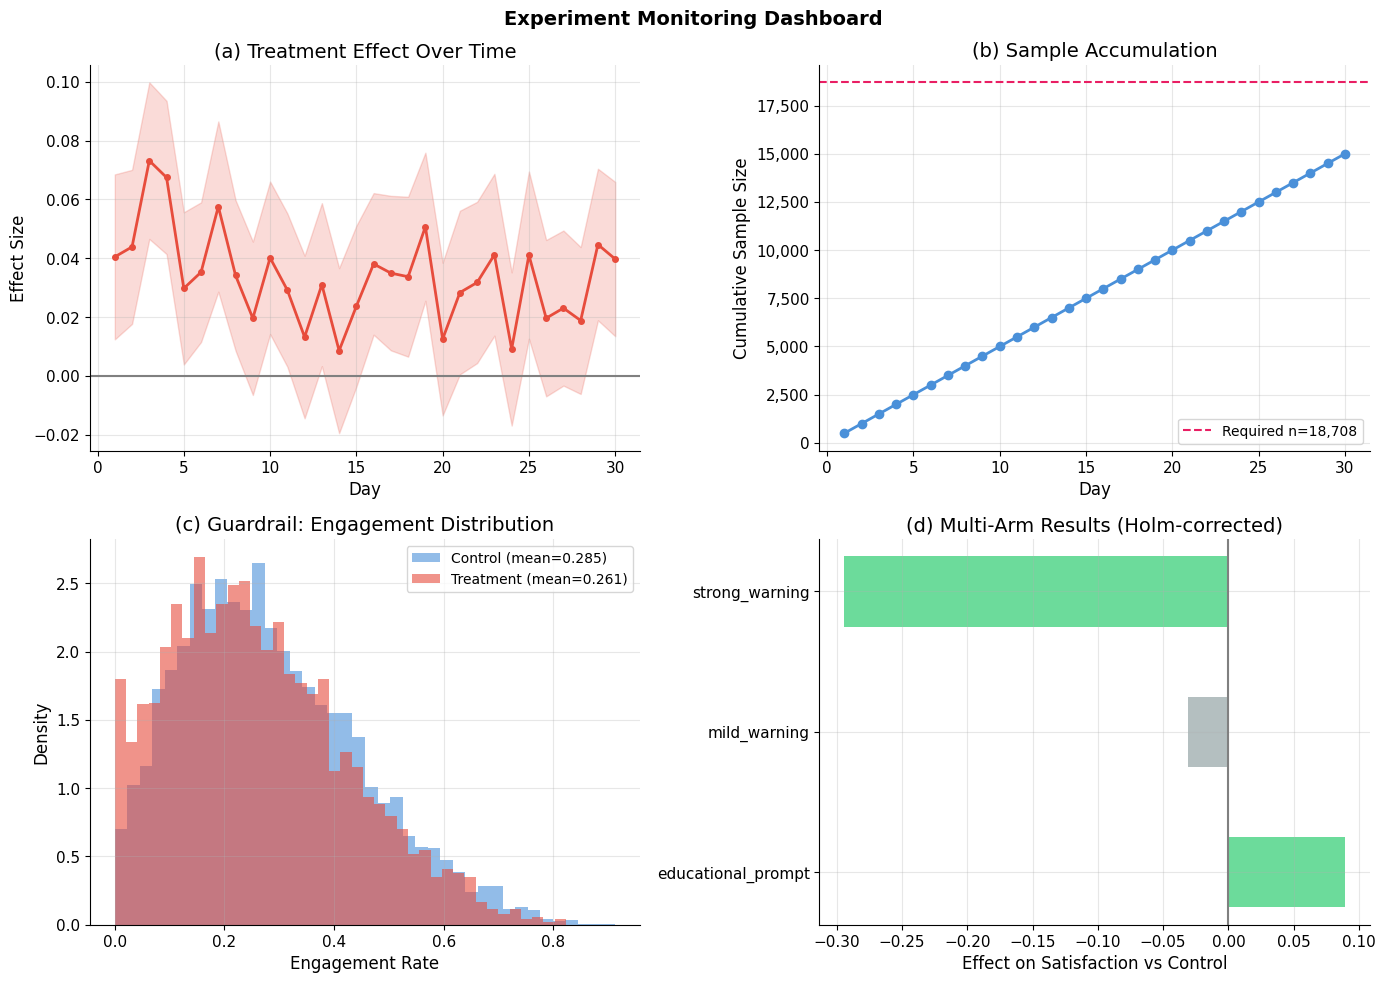

In [17]:
# 7. Experiment monitoring dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Experiment Monitoring Dashboard", fontsize=14, fontweight="bold")

# (a) Treatment effect over time
axes[0, 0].plot(effects_df["day"], effects_df["effect"], "o-",
               color=COLORS["treatment"], linewidth=2, markersize=4)
axes[0, 0].fill_between(effects_df["day"],
                        effects_df["effect"] - 1.96 * effects_df["se"],
                        effects_df["effect"] + 1.96 * effects_df["se"],
                        alpha=0.2, color=COLORS["treatment"])
axes[0, 0].axhline(0, color="gray", linestyle="-")
axes[0, 0].set_xlabel("Day")
axes[0, 0].set_ylabel("Effect Size")
axes[0, 0].set_title("(a) Treatment Effect Over Time")

# (b) Cumulative sample size
cum_n = effects_df["day"] * 500
axes[0, 1].plot(effects_df["day"], cum_n, "o-", color=COLORS["control"], linewidth=2)
axes[0, 1].axhline(n_primary, color=COLORS["danger"], linestyle="--",
                   label=f"Required n={n_primary:,}")
axes[0, 1].set_xlabel("Day")
axes[0, 1].set_ylabel("Cumulative Sample Size")
axes[0, 1].set_title("(b) Sample Accumulation")
axes[0, 1].legend()
axes[0, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"{x:,.0f}"))

# (c) Guardrail: engagement
ctrl_eng = ab_data[ab_data["group"]=="control"]["post_engagement_rate"]
treat_eng = ab_data[ab_data["group"]=="treatment"]["post_engagement_rate"]
axes[1, 0].hist(ctrl_eng, bins=40, alpha=0.6, color=COLORS["control"],
               label=f"Control (mean={ctrl_eng.mean():.3f})", density=True)
axes[1, 0].hist(treat_eng, bins=40, alpha=0.6, color=COLORS["treatment"],
               label=f"Treatment (mean={treat_eng.mean():.3f})", density=True)
axes[1, 0].set_xlabel("Engagement Rate")
axes[1, 0].set_ylabel("Density")
axes[1, 0].set_title("(c) Guardrail: Engagement Distribution")
axes[1, 0].legend()

# (d) Multi-arm comparison
arm_names_mv = [r["arm"] for r in results_table]
effects_mv = [r["effect"] for r in results_table]
colors_mv = [COLORS["accent"] if holm_result["adjusted_p_values"][i] < 0.05
             else COLORS["neutral"] for i in range(len(results_table))]
axes[1, 1].barh(range(len(arm_names_mv)), effects_mv, color=colors_mv, alpha=0.7, height=0.5)
axes[1, 1].axvline(0, color="gray", linestyle="-")
axes[1, 1].set_yticks(range(len(arm_names_mv)))
axes[1, 1].set_yticklabels(arm_names_mv)
axes[1, 1].set_xlabel("Effect on Satisfaction vs Control")
axes[1, 1].set_title("(d) Multi-Arm Results (Holm-corrected)")

plt.tight_layout()
plt.show()

## Summary & Key Takeaways

| Topic | Key Insight |
|-------|-------------|
| **Unit of diversion** | User-level for most experiments; cluster randomization reduces power (DEFF = 1 + (m-1)rho) |
| **Sample size** | Low base rates (1-5% violation rate) require large samples; 0.5pp MDE needs ~20K+ per arm |
| **Phased rollout** | Start at 1% canary then ramp to 50%; SRM check at each phase |
| **Multi-arm bandits** | Thompson Sampling concentrates traffic on best arm; reduces regret vs uniform allocation |
| **Novelty effects** | Compare early vs late cohorts; look for declining effect trends in first 7-14 days |
| **CUPED** | Pre-experiment covariates can reduce variance by 30-50%, equivalent to 1.5-2x sample size |
| **Multiple testing** | Holm correction controls FWER; BH controls FDR — choose based on error tolerance |

### Interview Tips
- Always state your metric taxonomy first (OEC, guardrail, diagnostic, data quality)
- Discuss practical constraints: engineering cost, user experience, ethical concerns
- Content safety experiments have unique challenges: low base rates, delayed effects, network spillovers
- Always mention CUPED — it shows you understand variance reduction beyond textbook power analysis
- Design documents should include a clear decision rule: "We will ship if OEC improves by >= X pp AND no guardrail degrades by > Y"